In [ ]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0a1f4f2d0a5aedbcad47fa49d47141727b2ab661b98cd1950b15f4cc18646ae0
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
from lifelines import CoxPHFitter
coxph=CoxPHFitter()
from lifelines.exceptions import ConvergenceError
from lifelines.exceptions import ConvergenceWarning
import warnings
import numpy as np
import time
import math
import pandas as pd

df_record={}

def c(a, b):
    return np.concatenate((a, b))

def rep(val, n):
    return np.ones(n,)*val

def sum_v_2d(x):
    # mat[i,j] = sum(x[i:j+1])
    cumsum = np.cumsum(x)
    mat_1=cumsum[None, :] - cumsum[:-1, None]
    mat = np.concatenate((cumsum[None, :], mat_1), axis=0)
    return np.triu(mat)

def mono_haz(df1_y1, df1_cov1, df1_delta, df1_truncation, adjust, beta_hat):
    z_k = np.unique(np.sort(c(df1_y1, df1_truncation)))
    z1 = np.unique(np.sort(df1_y1[df1_delta==1]))
    N = z_k.shape[0]
    death_sum = np.zeros(N,)
    risk_set = np.zeros(N,)
    exp_term = np.zeros(N,)
    lamda = np.zeros(N,)
    for h in range(N):
      #index = np.logical_and(df1_y1>=z_k[h], df1_truncation<=z_k[h])
        index = np.logical_and(df1_y1>z_k[h], df1_truncation<=z_k[h])
        risk_set[h] = np.sum(index)
        death_sum[h] = np.sum(z1==z_k[h])
        exp_term[h] = np.sum(np.exp(df1_cov1[index] * beta_hat))

    difference = np.diff(z_k)
    nom_2d = sum_v_2d(death_sum[:-1])
    if adjust:
        denom_2d = sum_v_2d(exp_term[:-1] * difference)
    else:
        denom_2d = sum_v_2d(risk_set[:-1] * difference)
    ratio_2d = nom_2d / (denom_2d + 1e-4*(denom_2d==0))

    for j in range(N-1):
        lamda[j] = np.max(np.min(ratio_2d[0:j+1, j:N-1], axis=1), axis=0)
    lamda[N-1] = lamda[N-2]
    return lamda, z_k

def baseline_survival_sim(t1, df1_y1, df1_cov1, df1_delta, df1_truncation, hazard_est):
    z_k = np.unique(np.sort(c(df1_y1, df1_truncation)))
    I = np.digitize(np.array([t1]), bins=z_k, right=True)-1
    first = np.concatenate((np.zeros(1), np.cumsum(np.diff(z_k) * hazard_est[:-1])))
    if I == -1:
        cumhaz1 = 0
        rest=0
    else:
        cumhaz1 = first[I]
        rest = (t1-z_k[I]) * hazard_est[I]
    integration = cumhaz1 + rest
    return np.exp(-integration)

def rweibull(n, shape, scale):
    return scale * np.random.weibull(a=shape, size=(n, ))

def med_weibull(shape,scale):
    return((-np.log(0.5))^(1/shape)*scale)

def main(a,x_time,x_q1,x_q3,n_trials,n_samples_old,method_i,modify=False, no_est=False,trun_scale=1200):
    surv_median_est = []
    surv_median_tsai = []
    surv_median_lopuha = []
    surv_median_breslow = []
    km_med=np.zeros(n_trials,)
    cox_med=np.zeros(n_trials,)
    cox_med_wmn=np.zeros(n_trials,)
    elapsed = 0
    save_data={"y1":[], "truncation":[], "cov1":[], "delta":[],
                "tsai_weibull":[], "wu_weibull":[], "lopuha_weibull":[],
               "breslow_weibull":[],"surv_res_breslow":[],
                "surv_res_est":[], "surv_res_tsai":[],"surv_res_lopuha":[],
               "tsai_zk":[], "wu_zk":[], "lopuha_zk":[],
               "death_sum":[],"exp_term":[],"beta_hat_wu":[],"beta_hat_lopuha":[]
               }
    min_t = None
    min_x = None

    dataframe_list=[]
    sample_size=[]
    tsai_size=[]
    error_index=[]

    for i in range(n_trials):
        tt1 = time.time()
        np.random.seed(i)
        n_samples = n_samples_old
        man1=rweibull(n_samples//2, shape=a, scale = 1000)
        cen1=rweibull(n_samples//2, shape=a, scale = 1000)
        woman2=rweibull(n_samples//2, shape=a, scale = 2000)
        cen2=rweibull(n_samples//2, shape=a, scale = 2000)
        censor=c(cen1, cen2)
        failure = c(man1, woman2)
        cov1 = c(rep(0, n_samples//2), rep(1, n_samples//2))
        delta = failure <= censor
        y1 = delta * failure + (1-delta) * censor
        # remove the violated y1 & truncation
        truncation = rweibull(n_samples, shape=a, scale=trun_scale)
        indices = np.where(truncation<=y1)[0]
        y1=y1[indices]
        cov1 = cov1[indices]
        delta = delta[indices]
        truncation = truncation[indices]
        n_samples = len(indices)
        truncation0 = np.zeros(n_samples)
        d = {'y1': y1, 'truncation': truncation,'delta': delta,'cov1': cov1, "trial_i":i+cov1*0}
        df2 = pd.DataFrame(data=d)
        if no_est:
            print("Trial", i)
            continue
        kmf.fit(durations=y1[cov1==0], event_observed=delta[cov1==0], entry=truncation[cov1==0])
        #kmf.fit(durations=y1[cov1==1], event_observed=delta[cov1==1], entry=truncation[cov1==1])
        km_med[i]=np.mean(kmf.survival_function_at_times(x_time))
        bashaz_index=np.digitize(x_time, bins=np.sort(y1), right=True)-1
        coxph.fit(df=df2,duration_col="y1",event_col="delta",entry_col='truncation',formula="cov1")
        beta_hat_wu=coxph.params_.iloc[0]
        if beta_hat_wu<-10:
            error_index.append(i)
        try:
            coxph.fit(df=df2,duration_col="y1",event_col="delta",formula="cov1")
        except ConvergenceError:
        #except ConvergenceWarning:
            print("⚠️ Warning: Cox model did not converge. Skipping this fit.")
            error_index.append(i)
        coxph.fit(df=df2,duration_col="y1",event_col="delta",formula="cov1")
        if i not in error_index:
            beta_hat_lopuha=coxph.params_.iloc[0]
            death_sum=np.zeros(n_samples,)
            exp_term=np.zeros(n_samples,)
            z_k = np.unique(np.sort(y1))
            z1 = np.unique(np.sort(y1[delta==1]))
            for l in range(n_samples):
                index = np.logical_and(y1>=z_k[l], truncation<=z_k[l])
                death_sum[l] = np.sum(z1==z_k[l])
                exp_term[l] = np.sum(np.exp(cov1[index] * beta_hat_wu))
            cox_med[i]=np.where(bashaz_index==-1, 1, np.exp(-np.cumsum(death_sum/exp_term))[bashaz_index])
            cox_med_wmn[i]=cox_med[i]**(np.exp(beta_hat_wu))
            tsai_weibull, tsai_zk = mono_haz(y1[cov1==0], cov1[cov1==0], delta[cov1==0], truncation[cov1==0],
                                  adjust=False, beta_hat=0)
            #tsai_weibull, tsai_zk = mono_haz(y1[cov1==1], cov1[cov1==1], delta[cov1==1], truncation[cov1==1],
            #                      adjust=False, beta_hat=0)
            wu_weibull, wu_zk = mono_haz(y1, cov1, delta, truncation, adjust=True, beta_hat=beta_hat_wu)
            lopuha_weibull, lopuha_zk = mono_haz(y1, cov1, delta, truncation0, adjust=True, beta_hat=beta_hat_lopuha)
            breslow_weibull, breslow_zk = mono_haz_breslow(y1, cov1, delta, truncation, adjust=True, beta_hat=beta_hat_wu)
            dataframe_list.append(df2.copy())
            if min_t is None:
                min_t = np.min([np.max(tsai_zk), np.max(wu_zk),np.max(lopuha_zk)])
            else:
                min_t = np.min([min_t, np.max(tsai_zk), np.max(wu_zk),np.max(lopuha_zk)])
            if min_x is None:
                min_x = np.min(y1)
            else:
                min_x = np.min([min_x, np.min(y1)])
            surv_res_est=baseline_survival_sim(x_time, y1, cov1, delta,truncation,hazard_est=wu_weibull)
            surv_res_est_wmn=surv_res_est**(np.exp(beta_hat_wu))
            surv_median_est.append(surv_res_est)
            #surv_median_est.append(surv_res_est_wmn)
            surv_res_lopuha=baseline_survival_sim(x_time, y1, cov1, delta,truncation0,hazard_est=lopuha_weibull)
            surv_res_lopuha_wmn=surv_res_lopuha**(np.exp(beta_hat_lopuha))
            surv_median_lopuha.append(surv_res_lopuha)
            #surv_median_lopuha.append(surv_res_lopuha_wmn)
            surv_res_tsai=baseline_survival_sim(x_time, y1[cov1==0], cov1[cov1==0], delta[cov1==0], truncation[cov1==0],hazard_est=tsai_weibull)
            #surv_res_tsai=baseline_survival_sim(x_time, y1[cov1==1], cov1[cov1==1], delta[cov1==1], truncation[cov1==1],hazard_est=tsai_weibull)
            surv_median_tsai.append(surv_res_tsai)
            surv_res_breslow=baseline_survival_sim(x_time, y1, cov1, delta,truncation,hazard_est=breslow_weibull)
            surv_median_breslow.append(surv_res_breslow)
            surv_res_breslow_wmn=surv_res_breslow**(np.exp(beta_hat_wu))

            dt = time.time() - tt1
            elapsed += dt
            eta = (n_trials - i - 1) * (elapsed / (i+1))
            #beta_hat=coxph.params_[0]
            #print("Trials:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs"%(i, n_trials, dt, elapsed, eta))
            #print(cox_q3[i])
            save_data["y1"].append(y1)
            save_data["tsai_zk"].append(tsai_zk)
            save_data["wu_zk"].append(wu_zk)
            save_data["cov1"].append(cov1)
            save_data["truncation"].append(truncation)
            save_data["delta"].append(delta)
            save_data["tsai_weibull"].append(tsai_weibull)
            save_data["wu_weibull"].append(wu_weibull)
            save_data["lopuha_weibull"].append(lopuha_weibull)
            save_data["breslow_weibull"].append(breslow_weibull)
            save_data["surv_res_est"].append(surv_res_est)
            save_data["surv_res_lopuha"].append(surv_res_lopuha)
            save_data["surv_res_tsai"].append(surv_res_tsai)
            save_data["surv_res_breslow"].append(surv_res_breslow)
            save_data["death_sum"].append(death_sum)
            save_data["exp_term"].append(exp_term)
            save_data["beta_hat_wu"].append(beta_hat_wu)
            save_data["beta_hat_lopuha"].append(beta_hat_lopuha)
            i1=len(surv_median_est)-1
            print("Trials:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs|beta.hat.wu:%.4f beta.hat.lopuha:%.4f| OUTPUT=wu:%.4f tsai:%.4f lopuha:%.4f breslow:%.4f cox:%.4f km:%.4f"%(i, n_trials, dt, elapsed, eta,beta_hat_wu,beta_hat_lopuha ,surv_median_est[i1].item(), surv_median_tsai[i1].item(),surv_median_lopuha[i1].item(),surv_median_breslow[i1].item(),cox_med[i].item(),km_med[i].item()))
            print("Trials:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs|curr_i:%04d OUTPUT=wu:%.4f tsai:%.4f lopuha:%.4f cox:%.4f km:%.4f"%(i, n_trials, dt, elapsed, eta, i1, surv_q1_est[i1].item(), surv_q1_tsai[i1].item(),surv_q1_lopuha[i1].item(),cox_q1[i].item(),km_q1[i].item()))
            print("Trials:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs|OUTPUT=wu:%.4f tsai:%.4f lopuha:%.4f cox:%.4f km:%.4f| min_x:%.4f min_t:%.4f  valid_n:%4d tsai_n:%4d"%(i, n_trials, dt, elapsed, eta,surv_q3_est[i1].item(), surv_q3_tsai[i1].item(),surv_q3_lopuha[i1].item(),cox_q3[i].item(),km_q3[i].item(),min_x, min_t, n_samples,len(y1[cov1==0])))
            sample_size.append(n_samples)
            tsai_size.append(len(y1[cov1==0]))
    if no_est==False:
        filtered_km_med = np.delete(km_med, error_index)
        filtered_cox_med = np.delete(cox_med, error_index)
        print("#"*40)
        print(error_index)
        print("#"*40)
        print(len(surv_median_est))
        print("#"*40)
        #| %.4f | %.4f
        print("Summary (med):   bias: %.4f| %.4f| %.4f| %.4f | %.4f| %.4f   variance: %.4f| %.4f| %.4f| %.4f| %.4f | %.4f avg_n:%4d|avg_tsai_n:%4d"%(
            np.mean(surv_median_est)-0.5,np.mean(surv_median_tsai)-0.5,
            np.mean(surv_median_lopuha)-0.5,np.mean(surv_median_breslow)-0.5,
            np.mean(filtered_cox_med)-0.5,np.mean(filtered_km_med)-0.5,
            np.std(surv_median_est,ddof=1),np.std(surv_median_tsai,ddof=1),
            np.std(surv_median_lopuha,ddof=1),np.std(surv_median_breslow,ddof=1),
            np.std(filtered_cox_med,ddof=1),np.std(filtered_km_med,ddof=1),
            np.mean(sample_size),np.mean(tsai_size)
        ))



    # save data
    from google.colab import drive
    drive.mount('/content/drive')
    if no_est==False:
        np.savez("/content/drive/My Drive/data_monotone_hazard.npz", data=save_data)
    pd.concat(dataframe_list).to_csv('/content/drive/My Drive/df_concat.csv')

    #df.to_csv('/content/drive/My Drive/df.csv')
if __name__ == "__main__":
    #main(a=1, x_time=693.1472,x_q1=2302.585,x_q3=105.3605,n_trials=1000,n_samples_old=100,trun_scale=50)
    #main(a=1, x_time=1386.294,x_q1=4605.17,x_q3=210.721,n_trials=1000,n_samples_old=100,trun_scale=50) #women
    #main(a=1, x_time=1386.294,x_q1=4605.17,x_q3=210.721,n_trials=1000,n_samples_old=1000,trun_scale=50)

    #main(a=2, x_time=832.5546,x_q1=1517.427,x_q3=324.5928,n_trials=1000,n_samples_old=1000,trun_scale=250)
    #main(a=2, x_time=832.5546,x_q1=1517.427,x_q3=324.5928,n_trials=1000,n_samples_old=100,trun_scale=250) #men
    #main(a=2, x_time=1665.109,x_q1=3034.854,x_q3=649.1857,n_trials=1000,n_samples_old=100,trun_scale=250)#women

    #main(a=4, x_time=1824.889,x_q1=2463.678,x_q3=1139.461,n_trials=1000,n_samples_old=1000,trun_scale=500)
    #main(a=4, x_time=1824.889,x_q1=2463.678,x_q3=1139.461,n_trials=1000,n_samples_old=100,trun_scale=500)#;women
    #main(a=4, x_time=912.4443,x_q1=1231.839,x_q3=569.7305,n_trials=1000,n_samples_old=1000,trun_scale=500)#men
    #main(a=4, x_time=912.4443,x_q1=1231.839,x_q3=569.7305,n_trials=1000,n_samples_old=100,trun_scale=500)

    #main(a=6, x_time=940.7428,x_q1=1149.13,x_q3=687.2472,n_trials=1000,n_samples_old=100,trun_scale=600) #men
    #main(a=6, x_time=1881.486,x_q1=2111.896,x_q3=1624.983,n_trials=1000,n_samples_old=100,trun_scale=600) #women
    #main(a=6, x_time=940.7428,x_q1=1149.13,x_q3=687.2472,n_trials=1000,n_samples_old=1000,trun_scale=600) #men
    #main(a=6, x_time=1881.486,x_q1=2111.896,x_q3=1624.983,n_trials=1000,n_samples_old=1000,trun_scale=600)

Trials:0000/1000  dt:6.164s  elapsed:6.164s  ETA:6158.188s|beta.hat.wu:-2.6095 beta.hat.lopuha:-2.6149| OUTPUT=wu:0.5112 tsai:0.5159 lopuha:0.5281 breslow:0.5165 cox:0.5055 km:0.5112
Trials:0000/1000  dt:6.164s  elapsed:6.164s  ETA:6158.188s|curr_i:0000 OUTPUT=wu:0.1183 tsai:0.1003 lopuha:0.1216 cox:0.1147 km:0.1213
Trials:0000/1000  dt:6.164s  elapsed:6.164s  ETA:6158.188s|OUTPUT=wu:0.9347 tsai:0.9326 lopuha:0.9550 cox:0.9257 km:0.9228| min_x:377.5206 min_t:1381.5167  valid_n: 935 tsai_n: 440
Trials:0001/1000  dt:3.157s  elapsed:9.322s  ETA:4651.533s|beta.hat.wu:-2.7236 beta.hat.lopuha:-2.7283| OUTPUT=wu:0.5210 tsai:0.5265 lopuha:0.5521 breslow:0.5161 cox:0.5115 km:0.5165
Trials:0001/1000  dt:3.157s  elapsed:9.322s  ETA:4651.533s|curr_i:0001 OUTPUT=wu:0.1022 tsai:0.0729 lopuha:0.1078 cox:0.1034 km:0.1113
Trials:0001/1000  dt:3.157s  elapsed:9.322s  ETA:4651.533s|OUTPUT=wu:0.8954 tsai:0.8932 lopuha:0.9418 cox:0.8780 km:0.8741| min_x:319.4844 min_t:1334.0673  valid_n: 949 tsai_n: 451
Tr

In [ ]:
# compute probability
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
# load data
loaded_data = np.load("/content/drive/My Drive/data_monotone_hazard_old.npz", allow_pickle=True)
print(loaded_data['data'].item().keys())
loaded_d=loaded_data['data'].item()
a=4 #shape
n_trials = len(loaded_d["truncation"])
times = np.linspace(116,1196, 100)
wu_item_list=[]
tsai_item_list=[]
lopuha_item_list=[]
breslow_item_list=[]
km_item_list=[]
cox_item_list=[]
true_prob=np.exp(-(times/1000)**a)
#true_prob=np.exp(-(times/2000)**a)
elapsed = 0

for i in range(len(times)):
    tt1 = time.time()
    wu_item_list.append([])
    tsai_item_list.append([])
    lopuha_item_list.append([])
    breslow_item_list.append([])
    km_item_list.append([])
    cox_item_list.append([])
    for trial_i in range(n_trials):
        n_samples = len(loaded_d["truncation"][trial_i])
        y1 = loaded_d["y1"][trial_i]
        cov1 = loaded_d["cov1"][trial_i]
        delta = loaded_d["delta"][trial_i]
        truncation = loaded_d["truncation"][trial_i]
        truncation0 = np.zeros(n_samples)
        wu_weibull = loaded_d["wu_weibull"][trial_i]
        tsai_weibull = loaded_d["tsai_weibull"][trial_i]
        lopuha_weibull = loaded_d["lopuha_weibull"][trial_i]
        breslow_weibull = loaded_d["breslow_weibull"][trial_i]
        death_sum = loaded_d["death_sum"][trial_i]
        exp_term  = loaded_d["exp_term"][trial_i]
        beta_hat_wu=loaded_d["beta_hat_wu"][trial_i]
        beta_hat_lopuha=loaded_d["beta_hat_lopuha"][trial_i]
        wu_item=baseline_survival_sim(times[i], y1, cov1, delta, truncation, hazard_est=wu_weibull)
        wu_item_wmn=wu_item**(np.exp(beta_hat_wu))
        tsai_item=baseline_survival_sim(times[i], y1[cov1==0], cov1[cov1==0], delta[cov1==0], truncation[cov1==0], hazard_est=tsai_weibull)
        lopuha_item=baseline_survival_sim(times[i], y1, cov1, delta, truncation0, hazard_est=lopuha_weibull)
        lopuha_item_wmn=lopuha_item**(np.exp(beta_hat_lopuha))
        breslow_item=baseline_survival_sim(times[i], y1, cov1, delta, truncation, hazard_est=breslow_weibull)
        breslow_item = breslow_item.item()
        #wu_item=wu_item_wmn.item()
        #lopuha_item=lopuha_item_wmn.item()
        tsai_item = tsai_item.item()
        lopuha_item = lopuha_item.item()
        wu_item_list[-1].append(wu_item)
        tsai_item_list[-1].append(tsai_item)
        lopuha_item_list[-1].append(lopuha_item)
        breslow_item_list[-1].append(breslow_item)
        kmf.fit(durations=y1[cov1==0], event_observed=delta[cov1==0], entry=truncation[cov1==0])
        km_item=np.mean(kmf.survival_function_at_times(times[i]))
        km_item_list[-1].append(km_item)
        bashaz_index=np.digitize(times[i], bins=np.sort(y1), right=True)-1
        cox_item=np.where(bashaz_index==-1, 1, np.exp(-np.cumsum(death_sum/exp_term))[bashaz_index])
        cox_item_list[-1].append(cox_item)
        #cox_item_list[-1].append(cox_item**(np.exp(beta_hat_wu)))
    dt = time.time() - tt1
    elapsed += dt
    eta = (len(times) - i - 1) * (elapsed / (i+1))
    print("Times:%04d/%04d  dt:%.3fs  elapsed:%.3fs  ETA:%.3fs"%(i, len(times), dt, elapsed, eta))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dict_keys(['y1', 'truncation', 'cov1', 'delta', 'tsai_weibull', 'wu_weibull', 'lopuha_weibull', 'breslow_weibull', 'surv_res_breslow', 'surv_res_est', 'surv_res_tsai', 'surv_res_lopuha', 'tsai_zk', 'wu_zk', 'lopuha_zk', 'death_sum', 'exp_term', 'beta_hat_wu', 'beta_hat_lopuha'])
Times:0000/0100  dt:13.940s  elapsed:13.940s  ETA:1380.088s
Times:0001/0100  dt:13.708s  elapsed:27.649s  ETA:1354.790s
Times:0002/0100  dt:13.410s  elapsed:41.059s  ETA:1327.579s
Times:0003/0100  dt:13.357s  elapsed:54.416s  ETA:1305.992s
Times:0004/0100  dt:13.447s  elapsed:67.863s  ETA:1289.406s
Times:0005/0100  dt:13.749s  elapsed:81.613s  ETA:1278.599s
Times:0006/0100  dt:13.638s  elapsed:95.250s  ETA:1265.468s
Times:0007/0100  dt:13.186s  elapsed:108.436s  ETA:1247.013s
Times:0008/0100  dt:13.692s  elapsed:122.128s  ETA:1234.852s
Times:0009/0100  dt:13.383s  elapsed:135.512s  ET

#Code for figure1

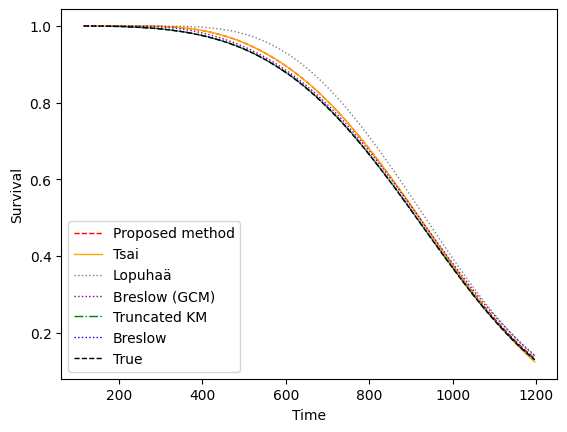

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# visualization

def type_flatten(tmp_item_list):
  new_item_list=[]
  for _item in tmp_item_list:
    new_item_list.append([xxx.item() for xxx in _item])
  return new_item_list


#times = np.linspace(110, 1190, 100)
times = np.linspace(116, 1196, 100)
#times = np.linspace(0, 2052, 100)
a=4 #shape
#times = np.linspace(14,2934, 100)
#times = np.linspace(116,2422, 100)
#times = np.linspace(238,2272, 100)
#times = np.linspace(0,4300, 100)
true_prob=np.exp(-(times/1000)**a)
wu_avg = np.mean(np.array(type_flatten(wu_item_list)), axis=-1)
tsai_avg = np.mean(np.array(tsai_item_list), axis=-1)
lopuha_avg = np.mean(np.array(lopuha_item_list), axis=-1)
breslow_avg=np.mean(np.array(breslow_item_list), axis=-1)
km_avg = np.mean(np.array(km_item_list), axis=-1)
#km_prob = pd.read_csv("/content/drive/My Drive/km.csv");
cox_avg = np.mean(np.array(cox_item_list), axis=-1)
linewidth=1
plt.plot(times, wu_avg, label="Proposed method", color="red", linestyle="--",linewidth=linewidth)
plt.plot(times, tsai_avg, label="Tsai", color="orange", linestyle="-", linewidth=linewidth)
plt.plot(times, lopuha_avg, label="Lopuhaä", color="grey", linestyle=":", linewidth=linewidth)
plt.plot(times, breslow_avg, label="Breslow (GCM)", color="purple", linestyle=":", linewidth=linewidth)
plt.plot(times, km_avg, label="Truncated KM", color="green", linestyle="-.", linewidth=linewidth)
#plt.plot(times, km_prob['mean.km'], label="Truncated KM", color="green", linestyle="-.", linewidth=linewidth)
plt.plot(times, cox_avg, label="Breslow", color="blue", linestyle=":", linewidth=linewidth)
plt.plot(times, true_prob, label="True", color="black", linestyle='--', linewidth=linewidth)
#plt.title('shape=4; trun=1200; bias: 0.0332| 0.0340| -0.1458   MCSE: 0.0702| 0.0720| 0.1831; N=1000', fontsize=10)

plt.legend()
plt.xlabel("Time")
plt.ylabel("Survival")
plt.show()
#'km_avg':km_avg,
result_df = pd.DataFrame(data={'wu_avg': wu_avg, 'tsai_avg': tsai_avg,'lopuha_avg': lopuha_avg,'breslow_avg': breslow_avg,'cox_avg': cox_avg,'true_prob': true_prob})
# save data
from google.colab import drive
drive.mount('/content/drive')
result_df.to_csv('/content/drive/My Drive/result_df.csv')